In [1]:
import pandas as pd
import numpy as np

In [88]:
pip install scikit-plots

   ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.6 MB 7.2 MB/s eta 0:00:01
   -------- ------------------------------- 1.6/7.6 MB 3.5 MB/s eta 0:00:02
   ----------- ---------------------------- 2.1/7.6 MB 4.2 MB/s eta 0:00:02
   --------------- ------------------------ 2.9/7.6 MB 3.5 MB/s eta 0:00:02
   ---------------- ----------------------- 3.1/7.6 MB 3.5 MB/s eta 0:00:02
   ---------------------- ----------------- 4.2/7.6 MB 3.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.2/7.6 MB 3.4 MB/s eta 0:00:01
   ---------------------- ----------------- 4.2/7.6 MB 3.4 MB/s eta 0:00:01
   ----------------------- ---------------- 4.5/7.6 MB 2.3 MB/s eta 0:00:02
   --------------------------- ------------ 5.2/7.6 MB 2.5 MB/s eta 0:00:01
   ------------------------------ --------- 5.8/7.6 MB 2.4 MB/s eta 0:00:01
   --------------------------------- ------ 6.3/7.6 MB 2.5 MB/s eta 0:00:01
   ----------------


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\shahr\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [89]:
import pickle
import itertools
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Pandas
import pandas as pd
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows', None)
pd.set_option('display.float_format', lambda x: '%.5f' % x)

# Numpy
import numpy as np

# Matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["font.family"] = "Sans"
plt.style.use('seaborn-v0_8-poster')



# Seaborn
import seaborn as sns
sns.set()

# Sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score, GridSearchCV,train_test_split,cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import scale,StandardScaler, MinMaxScaler,Normalizer,RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier

# Sklearn Metrics and Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import  accuracy_score, f1_score, precision_score,confusion_matrix, recall_score, roc_auc_score


# LightGBM
from lightgbm import LGBMClassifier

#XGBoost
from xgboost import XGBClassifier

# CatBoost
from catboost import CatBoostClassifier

# Statistics Testing
from scipy import stats
from scipy.stats import f_oneway
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

import scikitplot  as skplt

In [9]:
def dataInfo(X):
    print('='*10, 'DATA & FEATURE INFORMATION', '='*10)
    print(f'Data Rows: {X.shape[0]}')
    print(f'Data Columns: {X.shape[1]}')
    print(f'Duplicated Values: {X.duplicated().sum()}')
    missing_val = X.isnull().sum()
    missing_val_percentage = missing_val/len(X)*100
    data_type = X.dtypes
    unique_val = X.nunique()
    return pd.DataFrame({
        'Missing_val' : missing_val,
        'Missing_percentage' : missing_val_percentage,
        'Data_type' : data_type,
        'Unique_values' : unique_val
    }).sort_values('Missing_percentage',ascending=False)

In [10]:
def dataOutlier(X, col):
    q1 = X[col].quantile(0.25) # Finding the first quartile
    q3 = X[col].quantile(0.75) # Finding the third quartile
    iqr_val = stats.iqr(X[col]) # Finding the interquartile range
    lower = q1 - (1.5*iqr_val) # Lower limit for detecting outliers in the data
    upper = q3 + (1.5*iqr_val) # Upper limit for detecting outliers in the data

    outlier_list = X[col].apply(lambda x: 'outlier' if x < lower or x > upper else 'not-outlier')
    print(f'outlier lower limit: {lower}\noutlier upper limit: {upper}')
    return outlier_list

In [11]:
def lof_observation(df):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    df_num_cols = df.select_dtypes(include=numerics)
    df_outlier = df_num_cols.astype("float64")
    clf = LocalOutlierFactor(n_neighbors = 20, contamination = 0.1)
    clf.fit_predict(df_outlier)
    df_scores = clf.negative_outlier_factor_
    scores_df = pd.DataFrame(np.sort(df_scores))

    scores_df.plot(stacked=True, xlim = [0,20], color='r', title='Visualization of outliers according to the LOF method', style = '.-');                # first 20 observe
    th_val = np.sort(df_scores)[2]
    outliers = df_scores > th_val
    df = df.drop(df_outlier[~outliers].index)
    df.shape
    return df

In [12]:

def dataUnique(X):
    for x in X.columns:
        print(f'========== {x} ==========')
        print(f'{X[x].unique()}\n') # Printing all the unique values in the columns

In [13]:
def hist_boxplot(df, x_col, y_col=None, hue_col=None):
    color = '#F84030'
    if y_col is None:
        plt.figure(figsize=(10,10))
        plt.subplot(211)
        sns.boxplot(data=df, x=x_col, color=color)

        plt.subplot(212)
        sns.histplot(data=df, x=x_col, color=color)
        plt.tight_layout()
        plt.show()

    elif hue_col is None:
        plt.figure(figsize=(10,10))
        plt.subplot(211)
        sns.boxplot(data=df, x=x_col, y=y_col, color=color)

        plt.subplot(212)
        sns.histplot(data=df, x=x_col, y=y_col, color=color)
        plt.tight_layout()
        plt.show()

    else:
        plt.figure(figsize=(10,10))
        plt.subplot(211)
        sns.boxplot(data=df, x=x_col, y=y_col, hue=hue_col, color=color)

        plt.subplot(212)
        sns.histplot(data=df, x=x_col, y=y_col, hue=hue_col, color=color)
        plt.tight_layout()
        plt.show()

In [14]:
def plot_category_category(df, predictor, target):
    ax = ((df.groupby([predictor])[target].mean())/((df.groupby([predictor])[target].mean()).sum())*100).plot(kind='bar',figsize=(10,8), color = '#F84030')
    abs_values = round(((df.groupby([predictor])[target].mean())/((df.groupby([predictor])[target].mean()).sum())*100),1)
    ax.bar_label(container=ax.containers[0], labels=abs_values)

    plt.xticks(rotation=0);
    plt.ylabel('Churn Rate (%)',fontsize=12)
    plt.title(f'{predictor} vs Churn Rate (%)',fontsize=12)
    plt.xlabel(predictor,fontsize=12)
    plt.ylim(0,100)

    plt.show()

In [15]:
def plot_num_category(df, numeric, category):
    ax = (df.groupby([category])[numeric].median()).plot(kind='bar',figsize=(10,8), color = '#F84030')
    abs_values = round((df.groupby([category])[numeric].median()),1)
    ax.bar_label(container=ax.containers[0], labels=abs_values)

    plt.title(f'{numeric} vs {category}',fontsize=12)
    plt.ylabel(category,fontsize=12)
    plt.xlabel(numeric,fontsize=12)
    plt.xticks(rotation=0);
    plt.ylim(0,max(abs_values)+100)
    plt.show()

In [16]:
def anova(df, predictor_col, target_col):
    group1 = df[df[target_col]==1][predictor_col]
    group2 = df[df[target_col]==0][predictor_col]

    alpha = 0.05
    ftest, p_value = f_oneway(group1, group2)

    if p_value < alpha:
        print(f'Conclusion: p-value {p_value} is less than alpha {alpha}, ftest = {ftest}')
        print('There is a significant difference in the target based on the predictor.')
        print()
    else:
        print(f'Conclusion: p-value {p_value} is greater than alpha {alpha}, ftest = {ftest}')
        print('There is no significant difference in the target based on the predictor.')
        print()

In [17]:
def chi_test(df, predictor_col, target_col):
    obs = pd.crosstab(df[predictor_col], df[target_col])
    chi2, p, dof, expected = chi2_contingency(obs)
    alpha = 0.05

    if p < alpha:
        print(f'===== {predictor_col} =====')
        print('Number Expected:')
        print(expected)
        print()
        print(f'Chi-square Statistic: {chi2}, p-value: {p} less than {alpha}')
        print('There is a significant difference in the target based on the predictor.')
        print()
    else:
        print(f'===== {predictor_col} =====')
        print('Number Expected:')
        print(expected)
        print()
        print(f'Chi-square Statistic: {chi2}, p-value: {p} greater than {alpha}')
        print('There is no significant difference in the target based on the predictor.')
        print()

In [18]:
data = pd.read_csv("churn (1).csv")

In [19]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00000,1,1,1,101348.88000,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86000,1,0,1,112542.58000,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80000,3,1,0,113931.57000,1
3,4,15701354,Boni,699,France,Female,39,1,0.00000,2,0,0,93826.63000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82000,1,1,1,79084.10000,0


In [20]:
dataInfo(data)

========== DATA & FEATURE INFORMATION ==========
Data Rows: 10000
Data Columns: 14
Duplicated Values: 0


,Missing_val,Missing_percentage,Data_type,Unique_values
RowNumber,0,0.00000,int64,10000
CustomerId,0,0.00000,int64,10000
Surname,0,0.00000,object,2932
CreditScore,0,0.00000,int64,460
Geography,0,0.00000,object,3
Gender,0,0.00000,object,2
Age,0,0.00000,int64,70
Tenure,0,0.00000,int64,11
Balance,0,0.00000,float64,6382
NumOfProducts,0,0.00000,int64,4


In [21]:
dataUnique(data)

========== RowNumber ==========
[    1     2     3 ...  9998  9999 10000]

========== CustomerId ==========
[15634602 15647311 15619304 ... 15584532 15682355 15628319]

========== Surname ==========
['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']

========== CreditScore ==========
[619 608 502 699 850 645 822 376 501 684 528 497 476 549 635 616 653 587
 726 732 636 510 669 846 577 756 571 574 411 591 533 553 520 722 475 490
 804 582 472 465 556 834 660 776 829 637 550 698 585 788 655 601 656 725
 511 614 742 687 555 603 751 581 735 661 675 738 813 657 604 519 664 678
 757 416 665 777 543 506 493 652 750 729 646 647 808 524 769 730 515 773
 814 710 413 623 670 622 785 605 479 685 538 562 721 628 668 828 674 625
 432 770 758 795 686 789 589 461 584 579 663 682 793 691 485 650 754 535
 716 539 706 586 631 717 800 683 704 615 667 484 480 578 512 606 597 778
 514 525 715 580 807 521 759 516 711 618 643 671 689 620 676 572 695 592
 567 694 547 594 673 610 767 763 712 703 662

In [22]:

TARGET = "Exited"

In [23]:
data_new = data.copy()
data_new['Tenure'] =  data_new.Tenure.astype(float)
data_new['NumOfProducts'] =  data_new.NumOfProducts.astype(float)

In [24]:

data_new.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.00000,0.00000,1.00000,1,1,101348.88000,1
1,2,15647311,Hill,608,Spain,Female,41,1.00000,83807.86000,1.00000,0,1,112542.58000,0
2,3,15619304,Onio,502,France,Female,42,8.00000,159660.80000,3.00000,1,0,113931.57000,1
3,4,15701354,Boni,699,France,Female,39,1.00000,0.00000,2.00000,0,0,93826.63000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.00000,125510.82000,1.00000,1,1,79084.10000,0


In [25]:
numerical = ['CreditScore',
             'Age',
             'Tenure',
             'Balance',
             'NumOfProducts',
             'EstimatedSalary']
categorical =['RowNumber',
              'CustomerId',
              'Surname',
              'Geography',
              'Gender',
              'HasCrCard',
              'IsActiveMember',
              'Exited']

In [26]:

data_new[numerical].describe()

,CreditScore,Age,Tenure,Balance,NumOfProducts,EstimatedSalary
count,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000,10000.00000
mean,650.52880,38.92180,5.01280,76485.88929,1.53020,100090.23988
std,96.65330,10.48781,2.89217,62397.40520,0.58165,57510.49282
min,350.00000,18.00000,0.00000,0.00000,1.00000,11.58000
25%,584.00000,32.00000,3.00000,0.00000,1.00000,51002.11000
50%,652.00000,37.00000,5.00000,97198.54000,1.00000,100193.91500
75%,718.00000,44.00000,7.00000,127644.24000,2.00000,149388.24750
max,850.00000,92.00000,10.00000,250898.09000,4.00000,199992.48000


array([<Axes: ylabel='1'>], dtype=object)

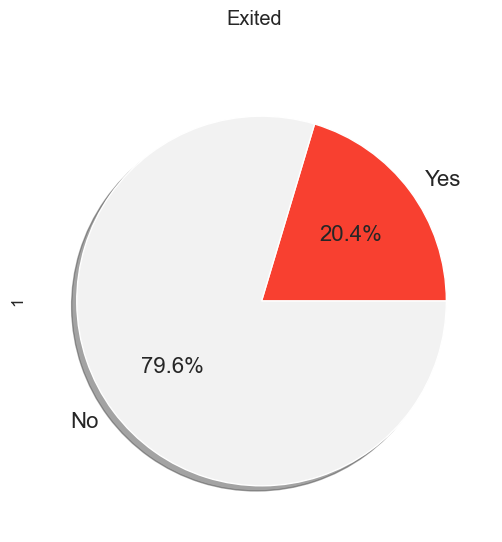

In [27]:
df_zero = data_new.query('Exited == 1')

# Count occurrences of each value
counts = df_zero['Exited'].value_counts()

plot_exited = pd.DataFrame({'Yes' : counts,'No' : len(data_new) - counts})

# Plot as pie chart
plot_exited.T.plot(kind = 'pie',subplots=True, legend =False, title = 'Exited', figsize = (6,6),colors=['#F84030','#F2F2F2'],
        shadow=True,
        autopct='%1.1f%%',
        textprops={'fontsize': 16})

In [28]:
(data_new[data_new[categorical] == 1][categorical].count())/len(data_new)*100

RowNumber         0.01000
CustomerId        0.00000
Surname           0.00000
Geography         0.00000
Gender            0.00000
HasCrCard        70.55000
IsActiveMember   51.51000
Exited           20.37000
dtype: float64

1. The average credit score of the customers is 650.53, which is considered fair.
2. The credit score ranges from 350 to 850, with 850 being the highest possible score.
3. The average age of the customers is 38.92 years, with a minimum of 18 and a maximum of 92.
4. The average tenure of the customers is 5.01 years, meaning they have been with the company for about 5 years on average. The tenure ranges from 0 to 10 years.
5. The average balance of the customers is 76485.89, with a large variation of 62397.41. The balance ranges from 0 to 250898.09, with some customers having no balance at all.
6. The average number of products used by the customers is 1.53, with a standard deviation of 0.58. The number of products ranges from 1 to 4, with most customers using either 1 or 2 products.
The average estimated salary of the customers is 100090.24, with a standard deviation of 57510.49. The estimated salary ranges from 11.58 to 199992.48, with a wide distribution of values.
7. The data also shows that 20.4% of the customers exited the company, which is a high churn rate. This could indicate that the company is not meeting the needs or expectations of its customers, or that there are better alternatives in the market.
8. 70.55% customer has a credit card, 51.51% customer is an active member

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.00000,0.00000,1.00000,1,1,101348.88000,1
1,2,15647311,Hill,608,Spain,Female,41,1.00000,83807.86000,1.00000,0,1,112542.58000,0
2,3,15619304,Onio,502,France,Female,42,8.00000,159660.80000,3.00000,1,0,113931.57000,1
3,4,15701354,Boni,699,France,Female,39,1.00000,0.00000,2.00000,0,0,93826.63000,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.00000,125510.82000,1.00000,1,1,79084.10000,0


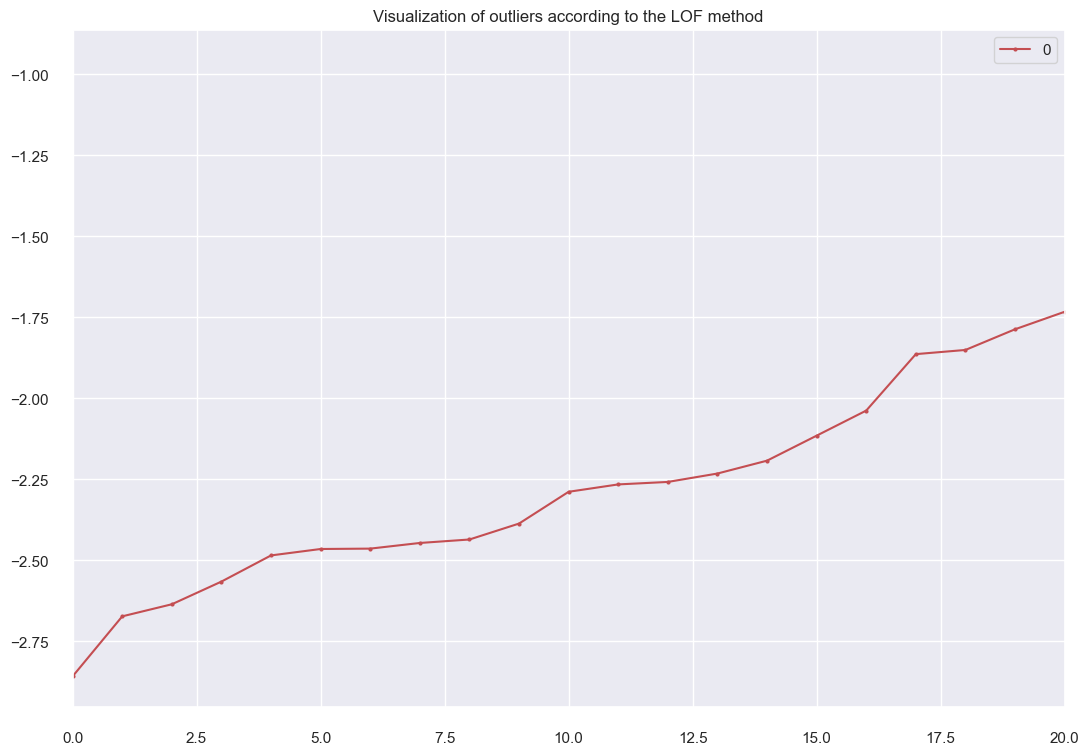

In [29]:
lof_observation(data_new).head()

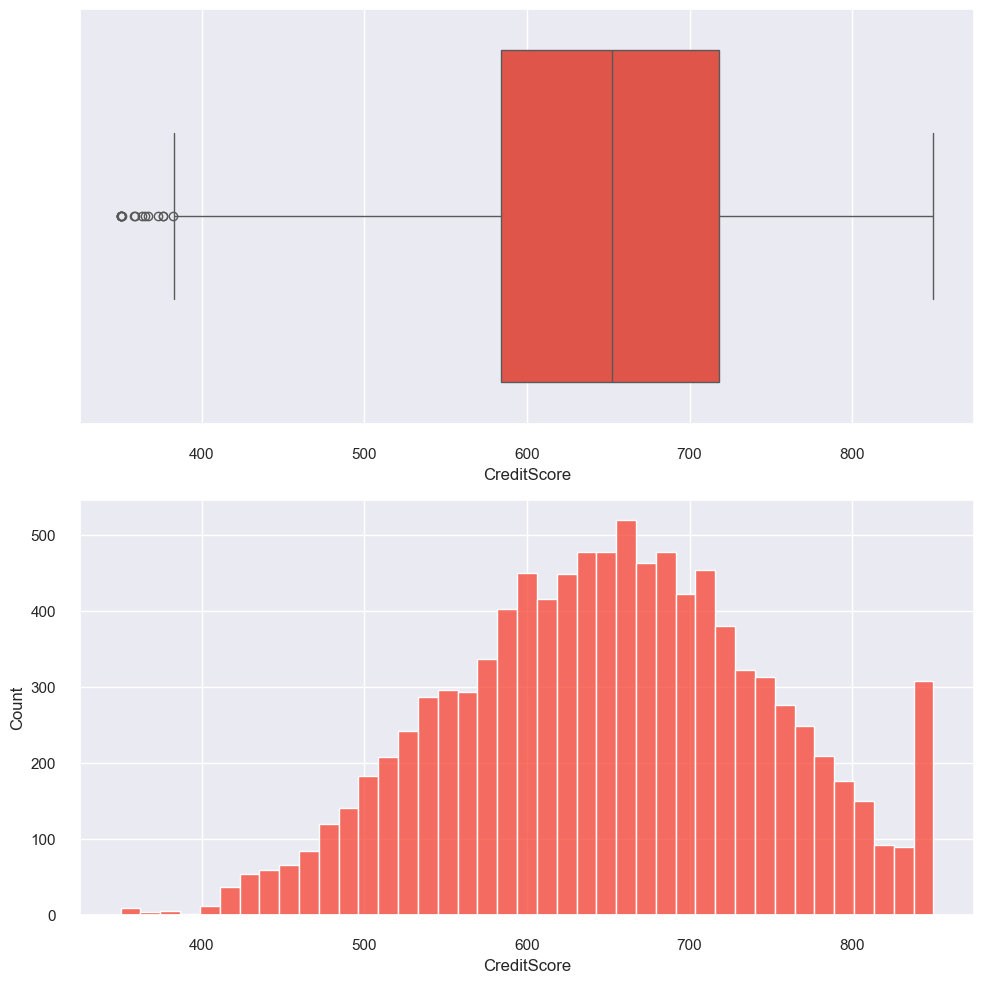

In [30]:
hist_boxplot(data_new,'CreditScore')

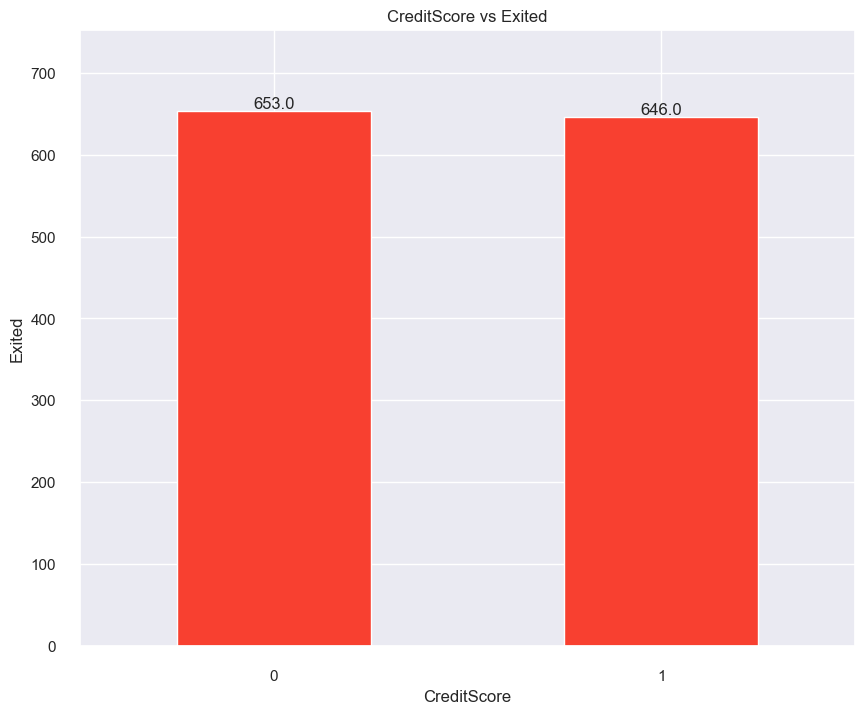

In [31]:
plot_num_category(data_new,'CreditScore',TARGET)

In [32]:
anova(data_new,'CreditScore',TARGET)

Conclusion: p-value 0.006738213892205325 is less than alpha 0.05, ftest = 7.344522163758236
There is a significant difference in the target based on the predictor.



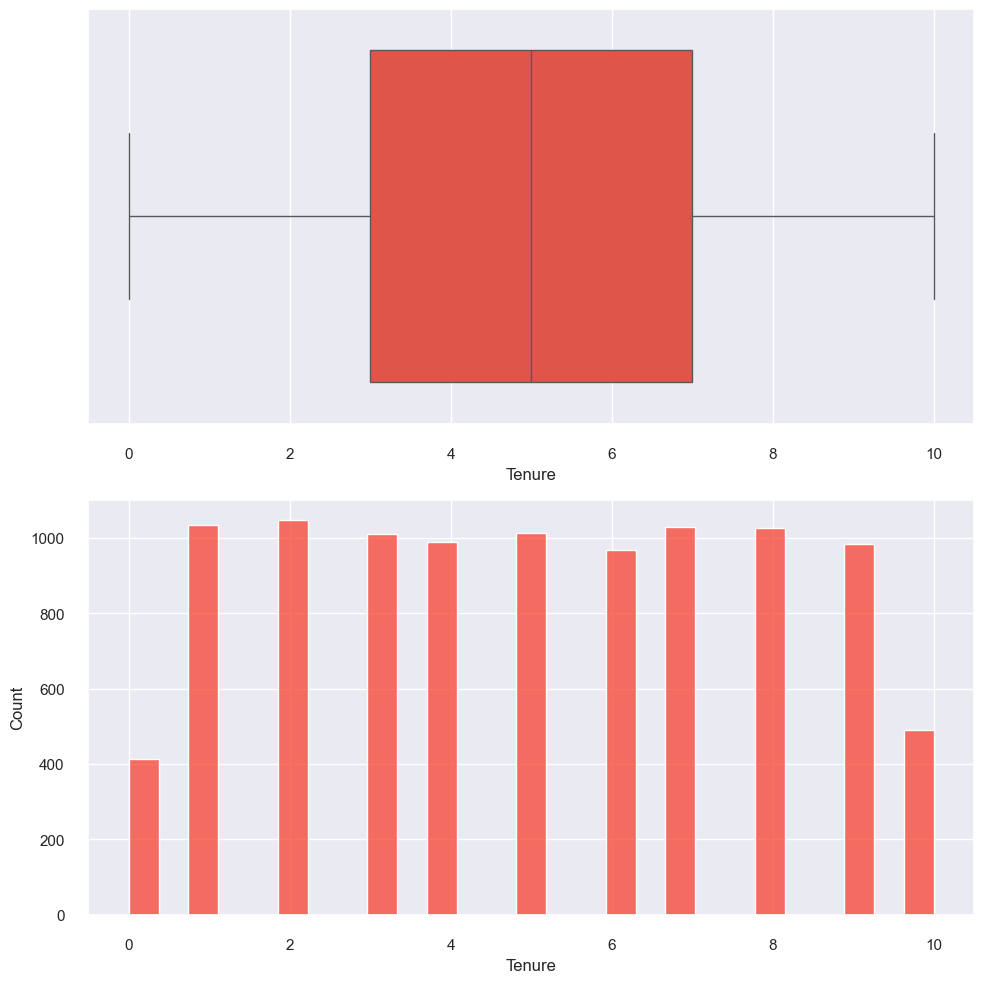

In [33]:
hist_boxplot(data_new,'Tenure')

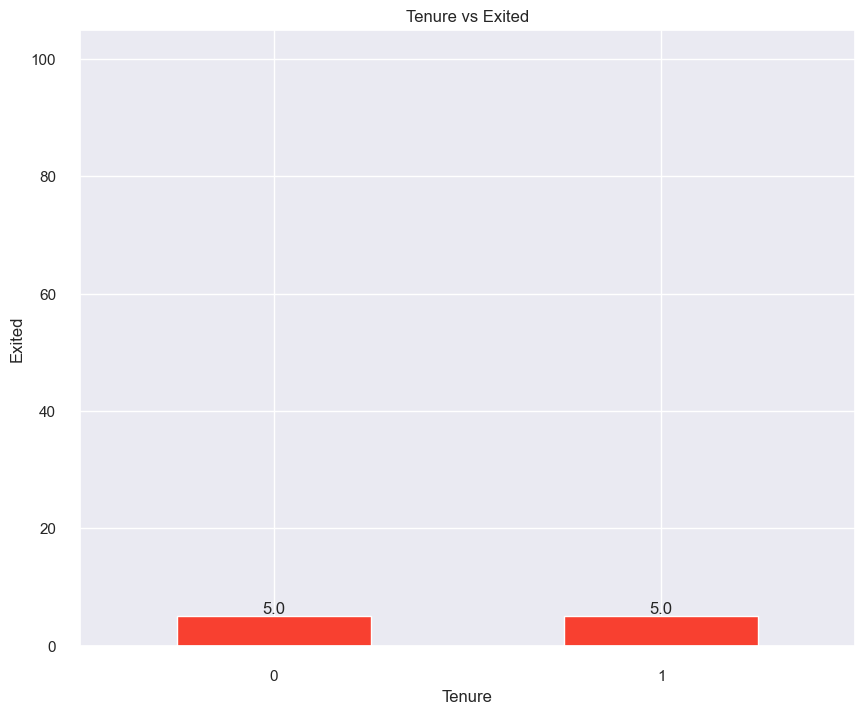

In [34]:
plot_num_category(data_new,'Tenure',TARGET)

In [35]:
anova(data_new,'Tenure',TARGET)

Conclusion: p-value 0.1615268494946745 is greater than alpha 0.05, ftest = 1.9601636261008142
There is no significant difference in the target based on the predictor.



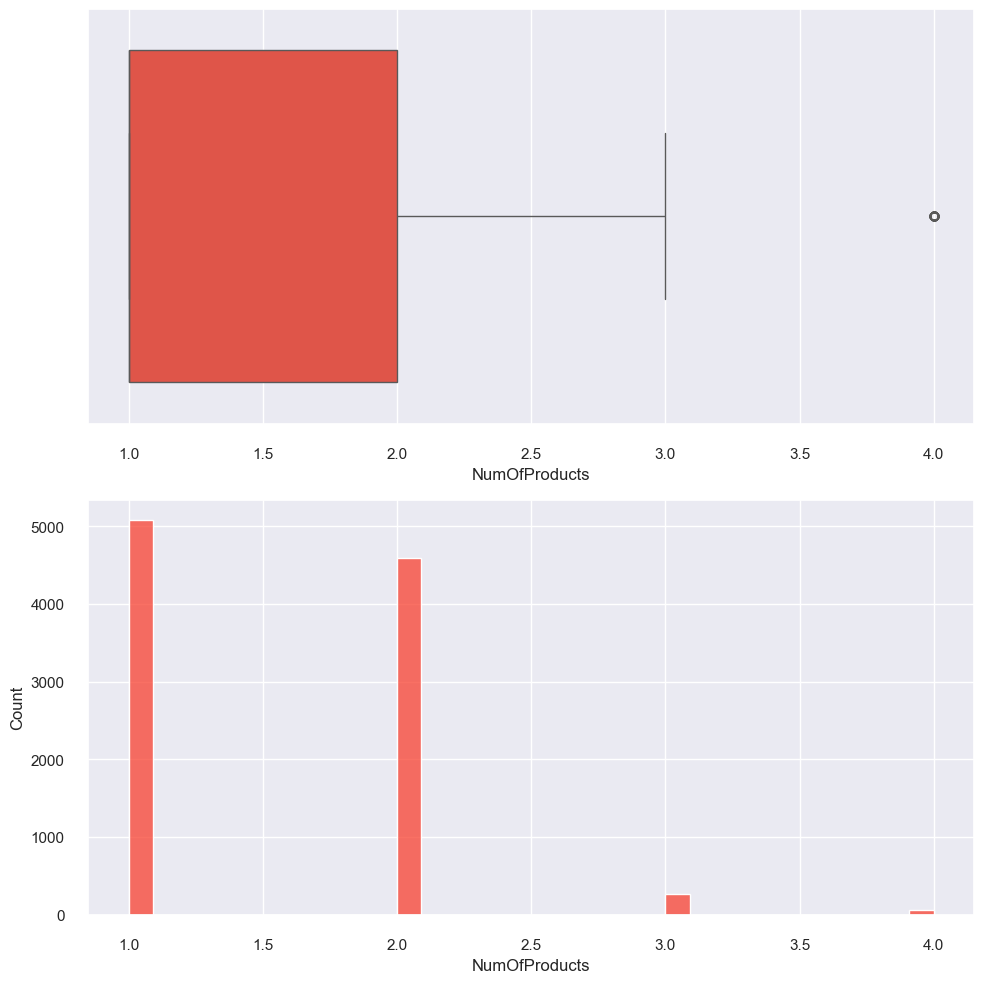

In [36]:
hist_boxplot(data_new,'NumOfProducts')

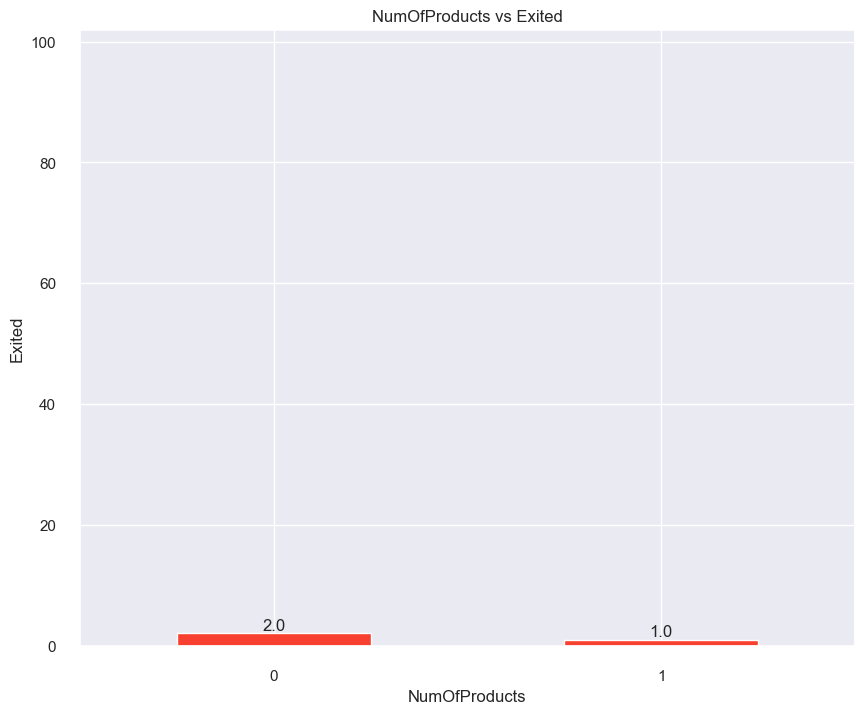

In [37]:
plot_num_category(data_new,'NumOfProducts',TARGET)

In [38]:
anova(data_new,'NumOfProducts',TARGET)

Conclusion: p-value 1.717333004806199e-06 is less than alpha 0.05, ftest = 22.915222502936913
There is a significant difference in the target based on the predictor.



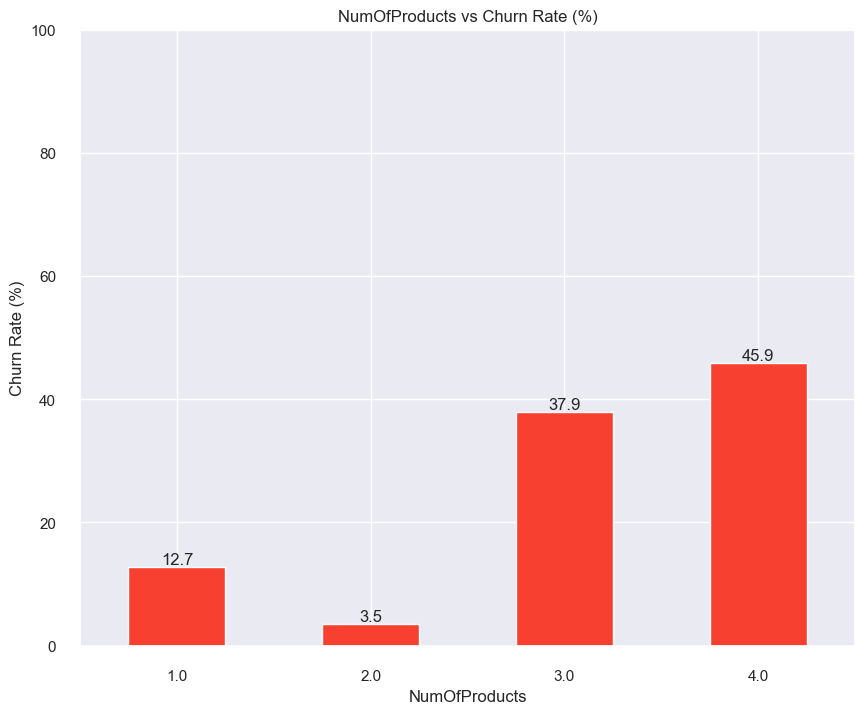

In [39]:
plot_category_category(data_new,'NumOfProducts',TARGET)

In [40]:
chi_test(data_new,'NumOfProducts', TARGET)

===== NumOfProducts =====
Number Expected:
[[4048.3892 1035.6108]
 [3655.017   934.983 ]
 [ 211.8158   54.1842]
 [  47.778    12.222 ]]

Chi-square Statistic: 1503.6293615070408, p-value: 0.0 less than 0.05
There is a significant difference in the target based on the predictor.



Customer using Product 3 and 4 are more likely to exit the bank

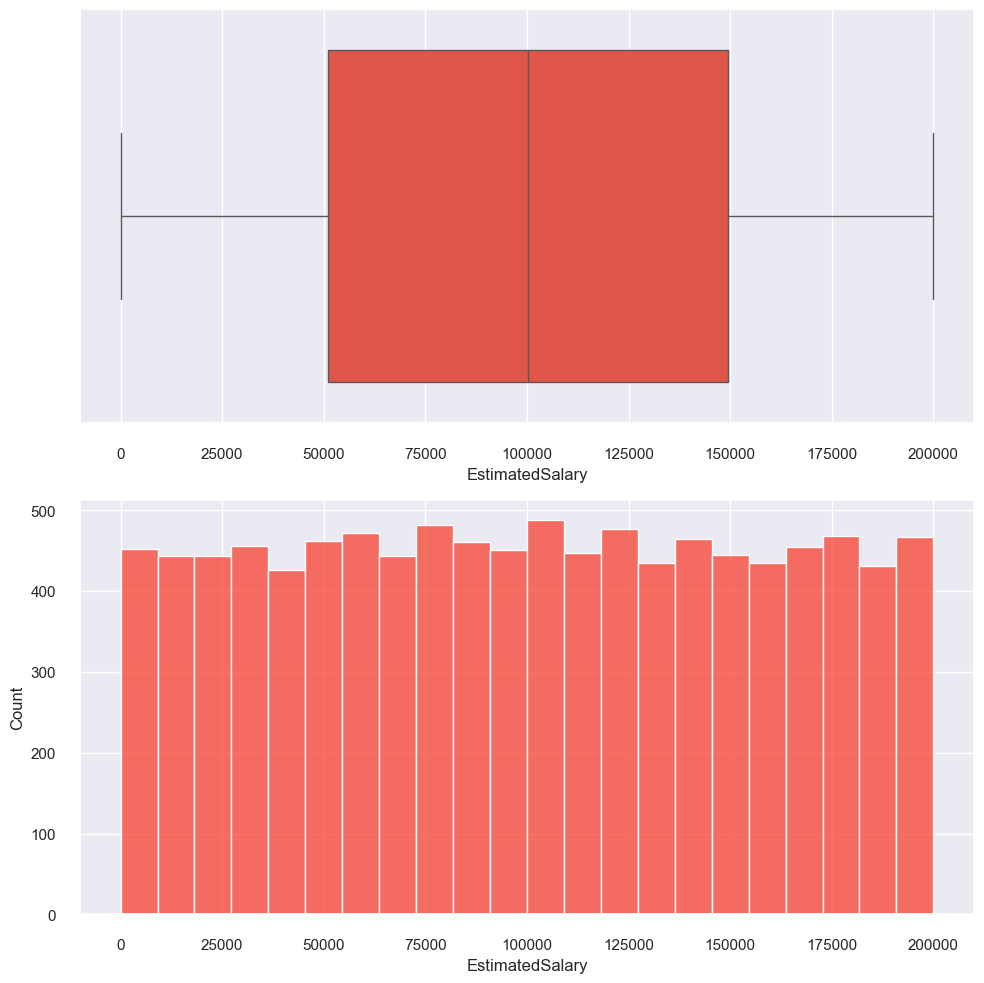

In [41]:
hist_boxplot(data_new,'EstimatedSalary')

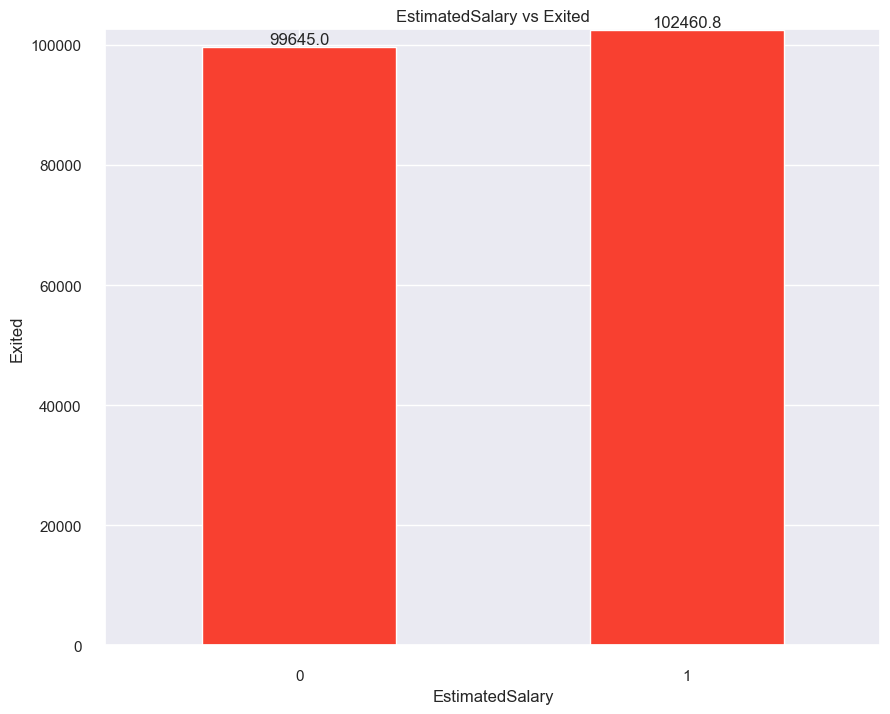

In [42]:

plot_num_category(data_new,'EstimatedSalary',TARGET)

In [43]:
anova(data_new,'EstimatedSalary',TARGET)

Conclusion: p-value 0.22644042802263928 is greater than alpha 0.05, ftest = 1.4632619239732483
There is no significant difference in the target based on the predictor.



Observation
* Salary doesnt corelate with exited

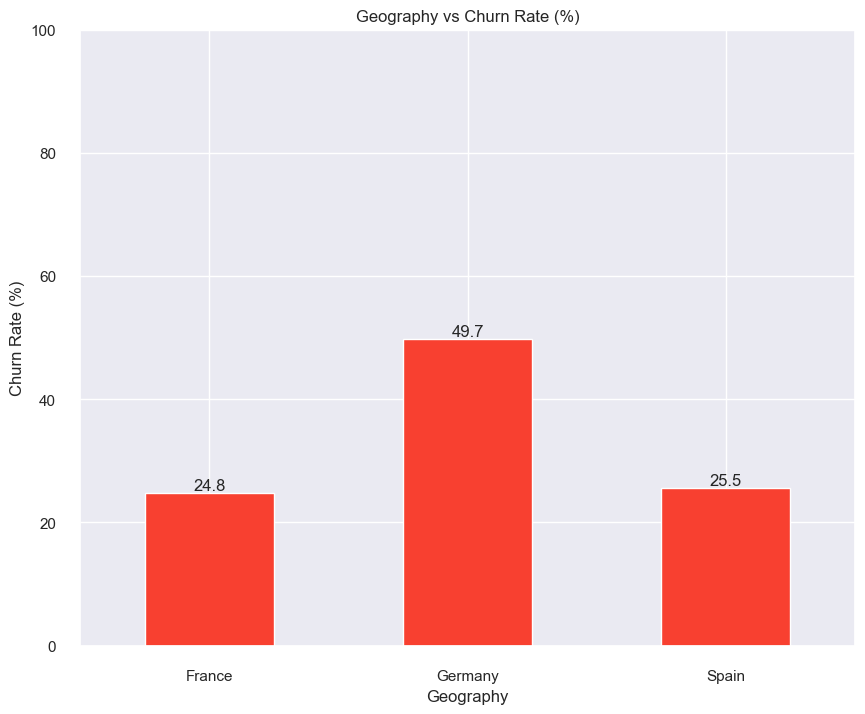

In [44]:
plot_category_category(data_new,'Geography',TARGET)

In [45]:
chi_test(data_new,'Geography', TARGET)

===== Geography =====
Number Expected:
[[3992.6482 1021.3518]
 [1997.9167  511.0833]
 [1972.4351  504.5649]]

Chi-square Statistic: 301.25533682434536, p-value: 3.8303176053541544e-66 less than 0.05
There is a significant difference in the target based on the predictor.



Observation
* Customer from Germany are more likely to leave the bank

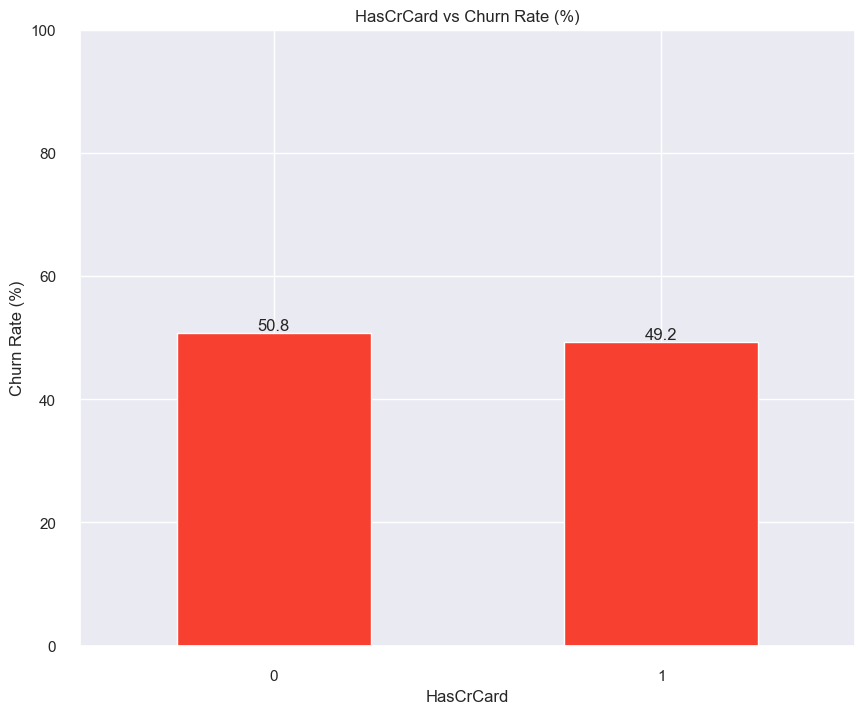

In [46]:
plot_category_category(data_new,'HasCrCard',TARGET)

In [47]:

chi_test(data_new,'HasCrCard', TARGET)

===== HasCrCard =====
Number Expected:
[[2345.1035  599.8965]
 [5617.8965 1437.1035]]

Chi-square Statistic: 0.47133779904440803, p-value: 0.49237236141554697 greater than 0.05
There is no significant difference in the target based on the predictor.



Obersvation
* Owning credit card or not doesnt have significant impact to customer exiting the bank

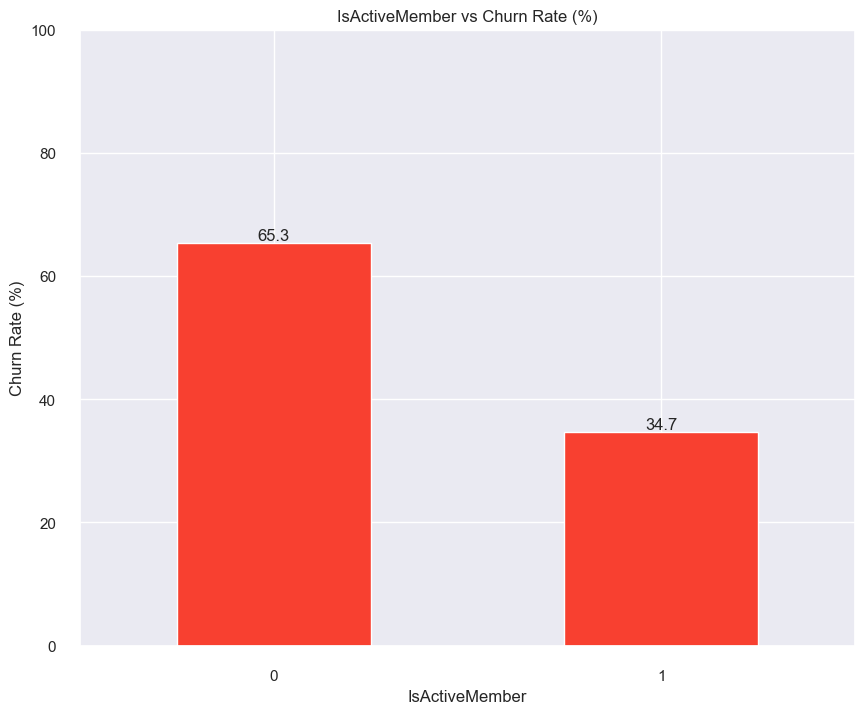

In [48]:
plot_category_category(data_new,'IsActiveMember',TARGET)

In [49]:

chi_test(data_new,'IsActiveMember', TARGET)

===== IsActiveMember =====
Number Expected:
[[3861.2587  987.7413]
 [4101.7413 1049.2587]]

Chi-square Statistic: 242.98534164287963, p-value: 8.785858269303705e-55 less than 0.05
There is a significant difference in the target based on the predictor.



Observation
* Active member are not likely to exit the bank

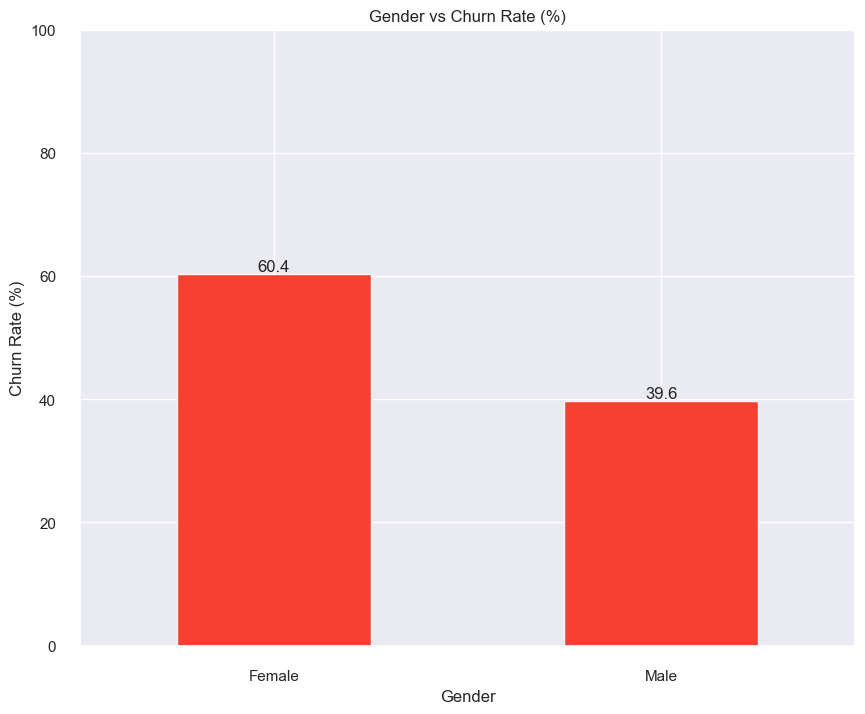

In [50]:

plot_category_category(data_new,'Gender',TARGET)

In [51]:
chi_test(data_new,'Gender', TARGET)

===== Gender =====
Number Expected:
[[3617.5909  925.4091]
 [4345.4091 1111.5909]]

Chi-square Statistic: 112.91857062096116, p-value: 2.2482100097131755e-26 less than 0.05
There is a significant difference in the target based on the predictor.



Observation
* Female customer are likely to leave the bank

In [53]:
def clear_outliers(df):
    # Suppress age and credit score
    for col in ["Age", "CreditScore"]:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        print(f"When {col} is printed below lower score: {lower} and upper score: {upper}")
        if col == "Age":
            df_outlier = df[col][(df[col] > upper)]
            df[col][df_outlier.index] = upper
        else:
            df_outlier = df[col][(df[col] < lower)]
            df[col][df_outlier.index] = lower
    return df

In [54]:
def outlier_process(df):
    # Process outliers
    df_outlier = lof_observation(df=df)
    df_outlier = clear_outliers(df=df_outlier)
    return df_outlier

When Age is printed below lower score: 14.0 and upper score: 62.0
When CreditScore is printed below lower score: 383.0 and upper score: 919.0


C:\Users\shahr\AppData\Local\Temp\ipykernel_22576\3021692042.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col][df_outlier.index] = upper
C:\Users\shahr\AppData\Local\Temp\ipykernel_22576\3021692042.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col][df_outlier.index] = lower


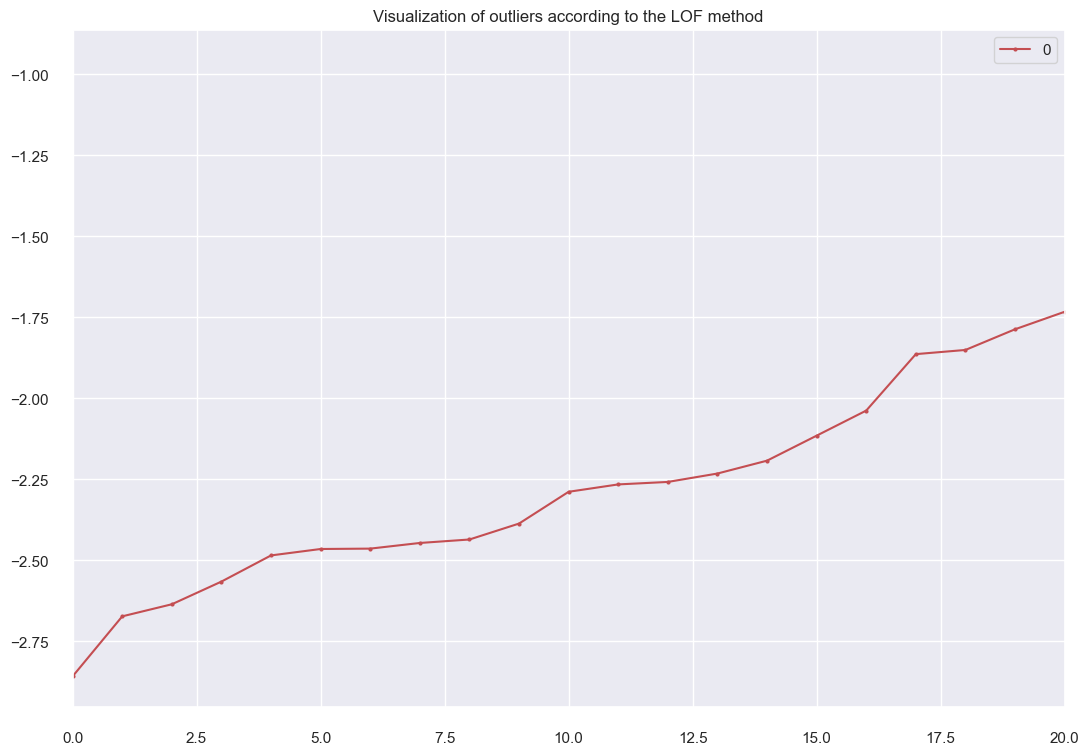

In [55]:
data_outlier = data_new.copy()
data_outlier = outlier_process(df = data_outlier)

In [56]:
def credit_score_table(row):
    credit_score = row.CreditScore
    if credit_score < 300:
        return "Deep"
    elif credit_score < 500:
        return "Very_Poor"
    elif credit_score < 601:
        return "Poor"
    elif credit_score < 661:
        return "Fair"
    elif credit_score < 781:
        return "Good"
    elif credit_score < 851:
        return "Excellent"
    else:
        return "Top"

In [57]:
def age_categorization(age):
    if age < 0:
        return "Invalid"
    elif age < 13:
        return "Child"
    elif age < 18:
        return "Teenager"
    elif age < 30:
        return "Young Adult"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

In [58]:
def age_tenure(row):
    age = row.Age
    tenure = row.Tenure
    return age*tenure

In [59]:
def age_tenure(row):
    age = row.Age
    tenure = row.Tenure
    return age*tenure

In [67]:
def product_utilization_rate_by_year(row):
    number_of_products = row.NumOfProducts
    tenure = row.Tenure

    if tenure == 0:
        return number_of_products
    else:
        rate = number_of_products / tenure
        return rate

In [60]:
def product_utilization_rate_by_estimated_salary(row):
    number_of_products = row.NumOfProducts
    estimated_salary = row.EstimatedSalary

    if estimated_salary == 0:
        return "Undefined"
    else:
        rate = number_of_products / estimated_salary
        return rate

In [61]:
def countries_monthly_average_salaries(row):
    # Monthly average salary taken from https://www.worlddata.info/average-income.php
    avg_salaries = {'France': 3680, 'Germany': 4305, 'Spain': 2474}

    salary = row.EstimatedSalary / 12
    country = row.Geography

    if country in avg_salaries:
        return salary / avg_salaries[country]
    else:
        return None

In [62]:
def balance_salary(row):
    balance = row.Balance
    salary = row.EstimatedSalary
    return balance/salary

In [63]:
def credit_score_squared(row):
    return (row.CreditScore)**2

In [64]:
def mean_financials(row):
    credit_score = row.CreditScore
    balance = row.Balance
    estimated_salary = row.EstimatedSalary

    mean_financials = (credit_score + balance + estimated_salary) / 3
    return mean_financials

In [68]:
def feature_engineering(df, is_show_graph=False):
    df_fe = df.copy()

    # balance_salary_rate
    df_fe['balance_salary_rate'] = df_fe.apply(lambda x: balance_salary(x), axis=1)

    # product_utilization_rate_by_year
    df_fe = df_fe.assign(product_utilization_rate_by_year=df_fe.apply(lambda x: product_utilization_rate_by_year(x), axis=1))

    # product_utilization_rate_by_estimated_salary
    df_fe = df_fe.assign(product_utilization_rate_by_estimated_salary=df_fe.apply(lambda x: product_utilization_rate_by_estimated_salary(x), axis=1))

    # tenure_rate_by_age
    df_fe['tenure_rate_by_age'] = df_fe.Tenure / (df_fe.Age - 17)

    # credit_score_rate_by_age
    df_fe['credit_score_rate_by_age'] = df_fe.CreditScore / (df_fe.Age - 17)

    # product_utilization_rate_by_salary
    df_fe['product_utilization_rate_by_salary'] = df_fe.Tenure / (df_fe.EstimatedSalary)

    # credit_score_rate_by_salary
    df_fe['credit_score_rate_by_salary'] = df_fe.CreditScore / (df_fe.EstimatedSalary)

    # mean_financials
    df_fe['mean_financials'] = df_fe.apply(lambda x: mean_financials(x), axis=1)

    # credit_score_squared
    df_fe['credit_score_squared'] = df_fe.apply(lambda x: credit_score_squared(x), axis=1)

    # age_tenure
    df_fe['age_tenure'] = df_fe.apply(lambda x: age_tenure(x), axis=1)

    # age_categorization
    df_fe['age_categorization'] = df_fe.Age.apply(lambda x: age_categorization(x))

    # credit_score_table
    df_fe = df_fe.assign(credit_score_table=df_fe.apply(lambda x: credit_score_table(x), axis=1))

    # countries_monthly_average_salaries
    df_fe = df_fe.assign(countries_monthly_average_salaries=df_fe.apply(lambda x: countries_monthly_average_salaries(x), axis=1))

    if is_show_graph:
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12))
        fig.tight_layout()
        sns.boxplot(y='balance_salary_rate', x=TARGET, hue=TARGET, data=df_fe, ax=axes[0][0])
        sns.boxplot(y='product_utilization_rate_by_year', x=TARGET, hue=TARGET, data=df_fe, ax=axes[0][1])
        plt.ylim(-1, 5)

    return df_fe

In [69]:
data_feature = feature_engineering(df = data_outlier)

In [70]:
data_feature.head(50)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,balance_salary_rate,product_utilization_rate_by_year,product_utilization_rate_by_estimated_salary,tenure_rate_by_age,credit_score_rate_by_age,product_utilization_rate_by_salary,credit_score_rate_by_salary,mean_financials,credit_score_squared,age_tenure,age_categorization,credit_score_table,countries_monthly_average_salaries
0,1,15634602,Hargrave,619,France,Female,42,2.00000,0.00000,1.00000,1,1,101348.88000,1,0.00000,0.50000,0.00001,0.08000,24.76000,0.00002,0.00611,33989.29333,383161,84.00000,Adult,Fair,2.29504
1,2,15647311,Hill,608,Spain,Female,41,1.00000,83807.86000,1.00000,0,1,112542.58000,0,0.74468,1.00000,0.00001,0.04167,25.33333,0.00001,0.00540,65652.81333,369664,41.00000,Adult,Fair,3.79084
2,3,15619304,Onio,502,France,Female,42,8.00000,159660.80000,3.00000,1,0,113931.57000,1,1.40137,0.37500,0.00003,0.32000,20.08000,0.00007,0.00441,91364.79000,252004,336.00000,Adult,Poor,2.57997
3,4,15701354,Boni,699,France,Female,39,1.00000,0.00000,2.00000,0,0,93826.63000,0,0.00000,2.00000,0.00002,0.04545,31.77273,0.00001,0.00745,31508.54333,488601,39.00000,Adult,Good,2.12470
4,5,15737888,Mitchell,850,Spain,Female,43,2.00000,125510.82000,1.00000,1,1,79084.10000,0,1.58706,0.50000,0.00001,0.07692,32.69231,0.00003,0.01075,68481.64000,722500,86.00000,Adult,Excellent,2.66384
5,6,15574012,Chu,645,Spain,Male,44,8.00000,113755.78000,2.00000,1,0,149756.71000,1,0.75960,0.25000,0.00001,0.29630,23.88889,0.00005,0.00431,88052.49667,416025,352.00000,Adult,Fair,5.04435
6,7,15592531,Bartlett,822,France,Male,50,7.00000,0.00000,2.00000,1,1,10062.80000,0,0.00000,0.28571,0.00020,0.21212,24.90909,0.00070,0.08169,3628.26667,675684,350.00000,Adult,Excellent,0.22787
7,8,15656148,Obinna,383,Germany,Female,29,4.00000,115046.74000,4.00000,1,0,119346.88000,1,0.96397,1.00000,0.00003,0.33333,31.91667,0.00003,0.00321,78258.87333,146689,116.00000,Young Adult,Very_Poor,2.31024
8,9,15792365,He,501,France,Male,44,4.00000,142051.07000,2.00000,0,1,74940.50000,0,1.89552,0.50000,0.00003,0.14815,18.55556,0.00005,0.00669,72497.52333,251001,176.00000,Adult,Poor,1.69702
9,10,15592389,H?,684,France,Male,27,2.00000,134603.88000,1.00000,1,1,71725.73000,0,1.87665,0.50000,0.00001,0.20000,68.40000,0.00003,0.00954,69004.53667,467856,54.00000,Young Adult,Good,1.62422


In [71]:
def data_encoding(df):
    df_model = df.copy()

    # Categorical columns
    non_encoding_columns = ["Geography", "HasCrCard", "IsActiveMember", "Gender", "NumOfProducts", "Tenure", "credit_score_table","age_categorization"]
    df_non_encoding = df_model[non_encoding_columns]
    df_model = df_model.drop(non_encoding_columns, axis=1)

    df_encoding = df_non_encoding.copy()

    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    df_encoding["gender_category"] = encoder.fit_transform(df_non_encoding.Gender)
    df_encoding["country_category"] = encoder.fit_transform(df_non_encoding.Geography)
    df_encoding["credit_score_category"] = encoder.fit_transform(df_non_encoding.credit_score_table)
    df_encoding["age_category"] = encoder.fit_transform(df_non_encoding.age_categorization)

    df_encoding.reset_index(drop=True, inplace=True)
    df_model.reset_index(drop=True, inplace=True)
    df_model = pd.concat([df_model, df_encoding], axis=1)

    # Drop unnecessary columns
    df_model = df_model.drop(["Geography", "Gender", "CustomerId", "Surname", "credit_score_table","age_categorization"], axis=1)

    # Encode HasCrCard and IsActiveMember as -1 for 0 values
    df_model.loc[df_model.HasCrCard == 0, 'HasCrCard'] = -1
    df_model.loc[df_model.IsActiveMember == 0, 'IsActiveMember'] = -1

    return df_model

In [72]:
data_encoded = data_encoding(data_feature)
data_encoded.head(20)

,RowNumber,CreditScore,Age,Balance,EstimatedSalary,Exited,balance_salary_rate,product_utilization_rate_by_year,product_utilization_rate_by_estimated_salary,tenure_rate_by_age,credit_score_rate_by_age,product_utilization_rate_by_salary,credit_score_rate_by_salary,mean_financials,credit_score_squared,age_tenure,countries_monthly_average_salaries,HasCrCard,IsActiveMember,NumOfProducts,Tenure,gender_category,country_category,credit_score_category,age_category
0,1,619,42,0.00000,101348.88000,1,0.00000,0.50000,0.00001,0.08000,24.76000,0.00002,0.00611,33989.29333,383161,84.00000,2.29504,1,1,1.00000,2.00000,0,0,1,0
1,2,608,41,83807.86000,112542.58000,0,0.74468,1.00000,0.00001,0.04167,25.33333,0.00001,0.00540,65652.81333,369664,41.00000,3.79084,-1,1,1.00000,1.00000,0,2,1,0
2,3,502,42,159660.80000,113931.57000,1,1.40137,0.37500,0.00003,0.32000,20.08000,0.00007,0.00441,91364.79000,252004,336.00000,2.57997,1,-1,3.00000,8.00000,0,0,3,0
3,4,699,39,0.00000,93826.63000,0,0.00000,2.00000,0.00002,0.04545,31.77273,0.00001,0.00745,31508.54333,488601,39.00000,2.12470,-1,-1,2.00000,1.00000,0,0,2,0
4,5,850,43,125510.82000,79084.10000,0,1.58706,0.50000,0.00001,0.07692,32.69231,0.00003,0.01075,68481.64000,722500,86.00000,2.66384,1,1,1.00000,2.00000,0,2,0,0
5,6,645,44,113755.78000,149756.71000,1,0.75960,0.25000,0.00001,0.29630,23.88889,0.00005,0.00431,88052.49667,416025,352.00000,5.04435,1,-1,2.00000,8.00000,1,2,1,0
6,7,822,50,0.00000,10062.80000,0,0.00000,0.28571,0.00020,0.21212,24.90909,0.00070,0.08169,3628.26667,675684,350.00000,0.22787,1,1,2.00000,7.00000,1,0,0,0
7,8,383,29,115046.74000,119346.88000,1,0.96397,1.00000,0.00003,0.33333,31.91667,0.00003,0.00321,78258.87333,146689,116.00000,2.31024,1,-1,4.00000,4.00000,0,1,4,2
8,9,501,44,142051.07000,74940.50000,0,1.89552,0.50000,0.00003,0.14815,18.55556,0.00005,0.00669,72497.52333,251001,176.00000,1.69702,-1,1,2.00000,4.00000,1,0,3,0
9,10,684,27,134603.88000,71725.73000,0,1.87665,0.50000,0.00001,0.20000,68.40000,0.00003,0.00954,69004.53667,467856,54.00000,1.62422,1,1,1.00000,2.00000,1,0,2,2


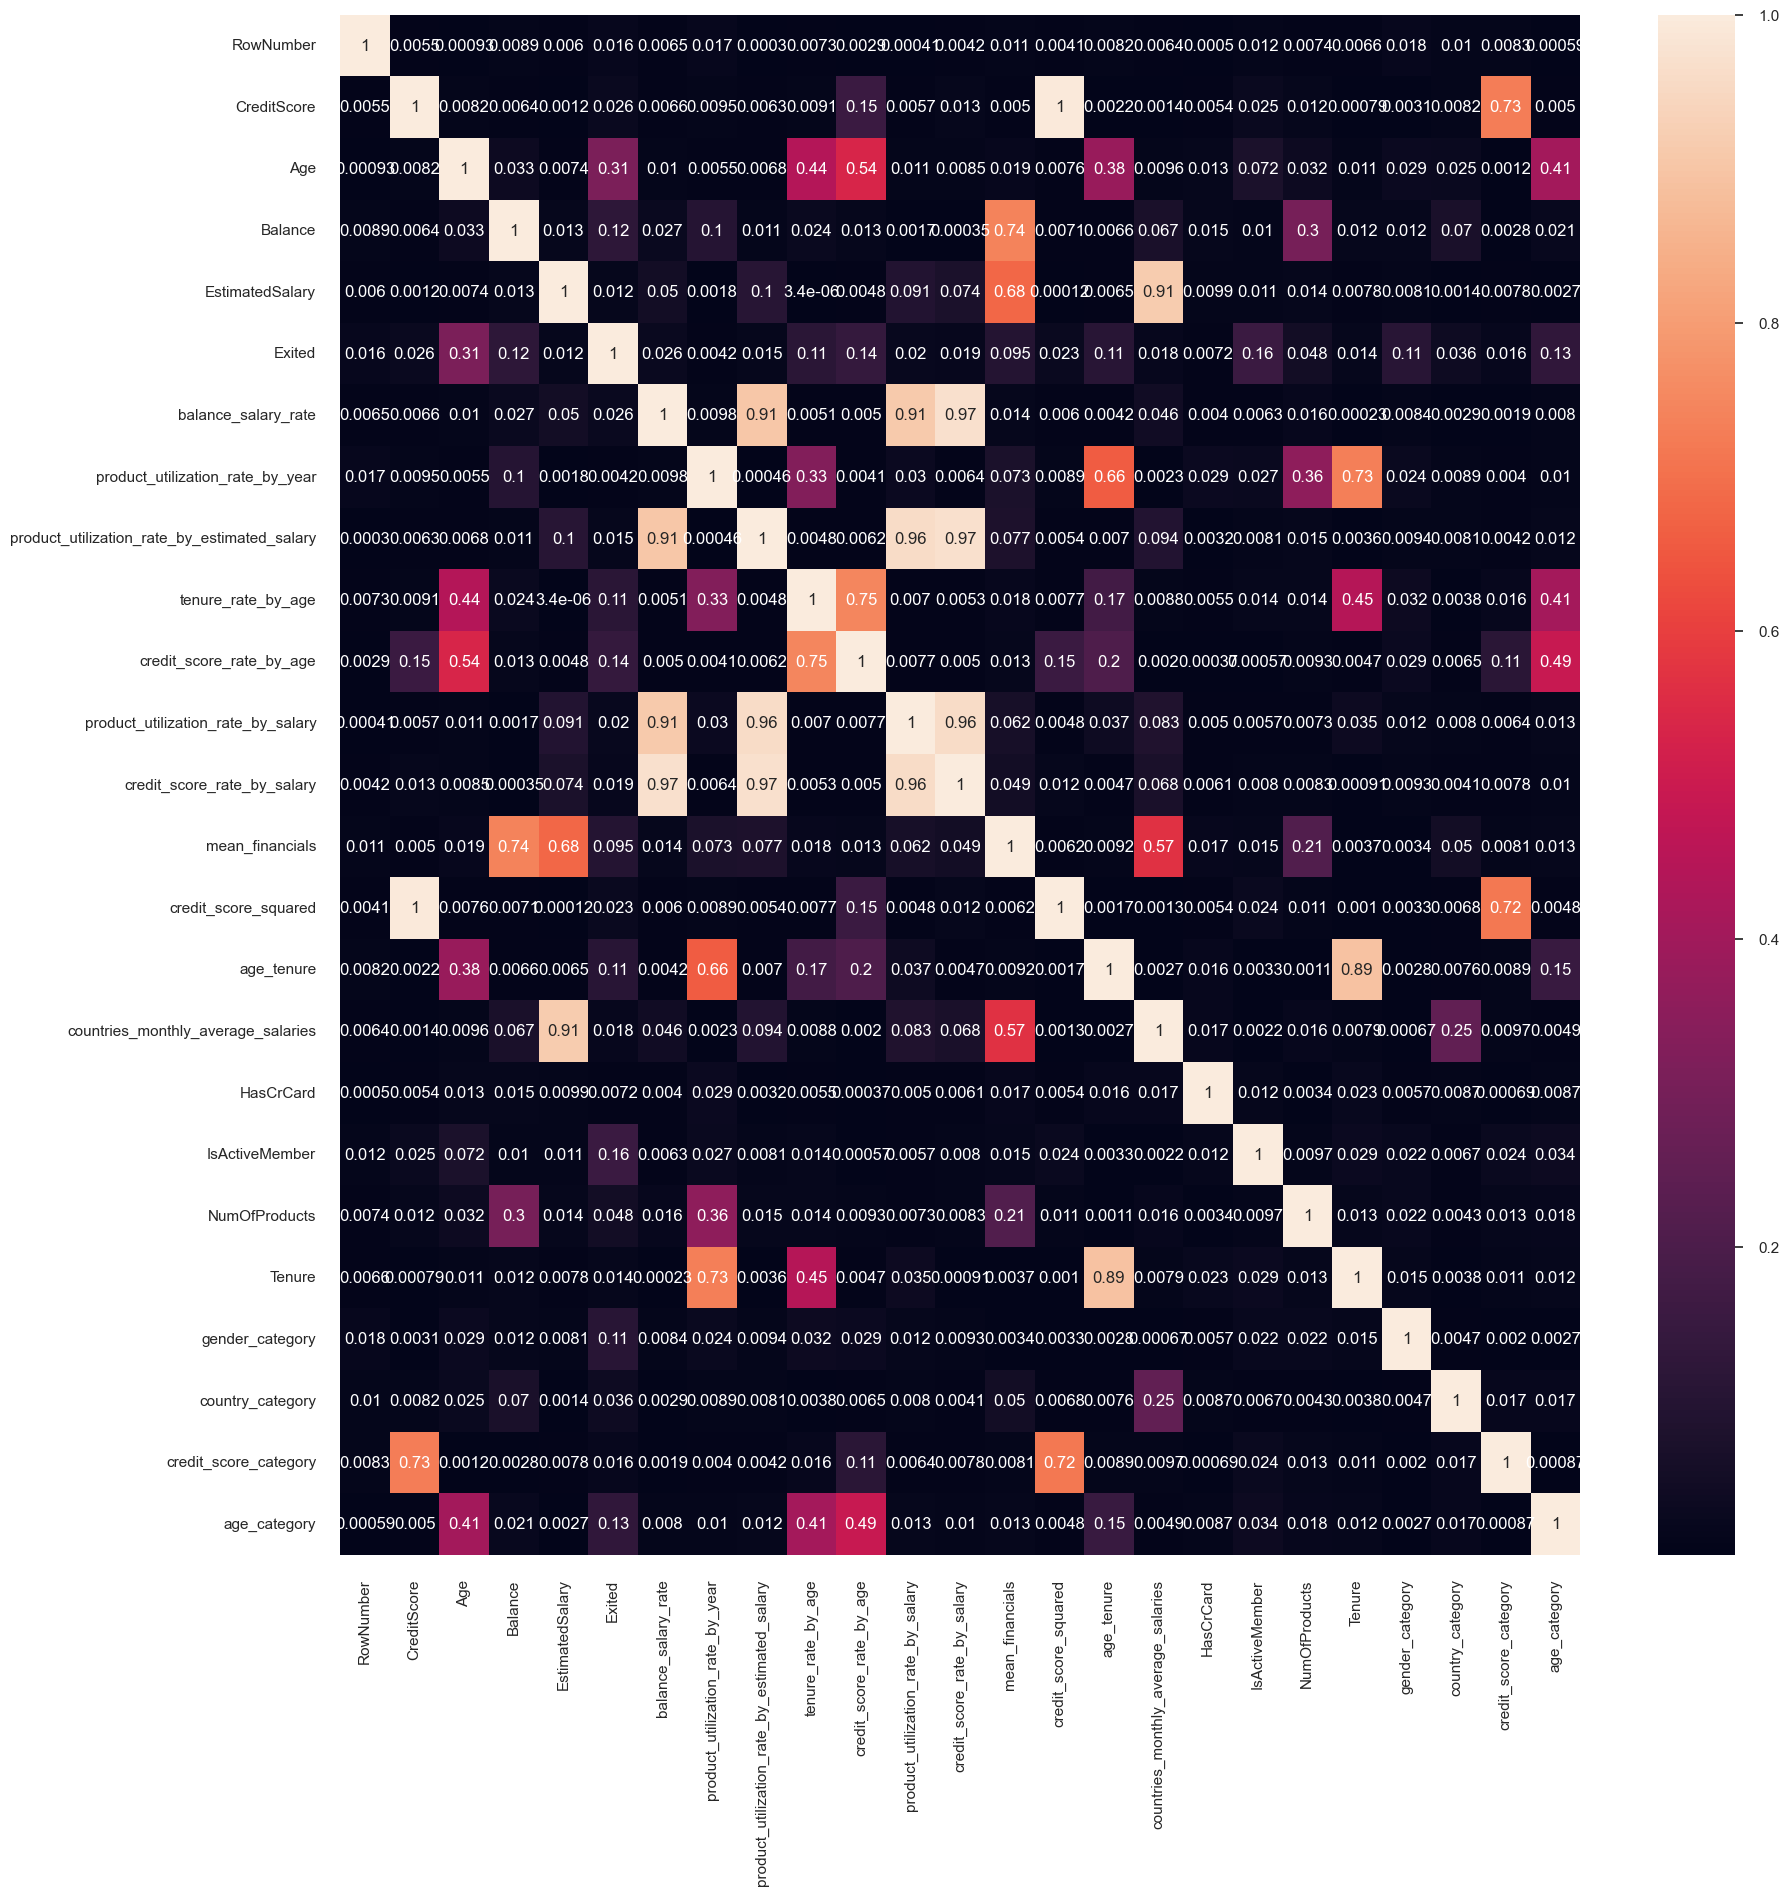

In [73]:
correlation = data_encoded.corr().abs()
plt.figure(figsize=(20,20))
sns.heatmap(correlation, annot=True)
plt.show()

In [75]:
corrs_results = data_encoded.corrwith(data_encoded["Exited"]).abs().nlargest(24)
corrs_results

Exited                                         1.00000
Age                                            0.31293
IsActiveMember                                 0.15588
credit_score_rate_by_age                       0.13949
age_category                                   0.12634
Balance                                        0.11865
tenure_rate_by_age                             0.11274
age_tenure                                     0.10626
gender_category                                0.10624
mean_financials                                0.09481
NumOfProducts                                  0.04775
country_category                               0.03575
CreditScore                                    0.02617
balance_salary_rate                            0.02557
credit_score_squared                           0.02347
product_utilization_rate_by_salary             0.02030
credit_score_rate_by_salary                    0.01918
countries_monthly_average_salaries             0.01811
RowNumber 

In [76]:
def model_prepare(df_model):
    y = df_model[TARGET]
    X = df_model.drop(TARGET, axis=1)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)

    from sklearn.preprocessing import StandardScaler
    sc = StandardScaler()
    X_train = sc.fit_transform(X_train)
    X_test = sc.transform(X_test)

    return X_train, X_test, y_train, y_test

In [77]:
X_train, X_test, y_train, y_test = model_prepare(df_model = data_encoded)

In [78]:
logr_model = LogisticRegression()
logr_model.fit(X_train, y_train)
y_pred = logr_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred, digits=4))
print(f"Accuracy score of Logistic Regression: {accuracy:.4f}")

              precision    recall  f1-score   support

           0     0.8259    0.9691    0.8918      2365
           1     0.6756    0.2394    0.3535       635

    accuracy                         0.8147      3000
   macro avg     0.7508    0.6043    0.6227      3000
weighted avg     0.7941    0.8147    0.7779      3000

Accuracy score of Logistic Regression: 0.8147


In [79]:
def data_training(X_train, X_test, y_train, y_test):
    models = [
        ('LOGR', LogisticRegression()),
        ('KNN', KNeighborsClassifier()),
        ('CART', DecisionTreeClassifier()),
        ('RF', RandomForestClassifier()),
        ('GBM', GradientBoostingClassifier()),
        ('XGBoost', XGBClassifier()),
        ('LightGBM', LGBMClassifier()),
        ('CatBoost', CatBoostClassifier(verbose=0))
    ]

    df_result = pd.DataFrame(columns=["model", "accuracy_score", "scale_method", "0_precision", "0_recall", "1_precision", "1_recall"])
    for name, model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, digits=2, output_dict=True)
        zero_report = class_report['0']
        one_report = class_report['1']
        df_result = pd.concat([df_result, pd.DataFrame({
            'model': [name],
            'accuracy_score': [score],
            'scale_method': ['NA'],
            '0_precision': [zero_report['precision']],
            '0_recall': [zero_report['recall']],
            '1_precision': [one_report['precision']],
            '1_recall': [one_report['recall']]
        })], ignore_index=True)

    return df_result.sort_values("accuracy_score", ascending=False)

In [80]:
training_result = data_training(X_train, X_test, y_train, y_test)
training_result

[LightGBM] [Info] Number of positive: 1401, number of negative: 5596
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001400 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3659
[LightGBM] [Info] Number of data points in the train set: 6997, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200229 -> initscore=-1.384866
[LightGBM] [Info] Start training from score -1.384866


,model,accuracy_score,scale_method,0_precision,0_recall,1_precision,1_recall
6,LightGBM,0.85333,NA,0.87524,0.94926,0.72414,0.49606
7,CatBoost,0.85300,NA,0.87057,0.95560,0.74010,0.47087
3,RF,0.85200,NA,0.86702,0.95941,0.74935,0.45197
4,GBM,0.85100,NA,0.86659,0.95856,0.74479,0.45039
5,XGBoost,0.84367,NA,0.87089,0.94123,0.68694,0.48031
0,LOGR,0.81467,NA,0.82595,0.96913,0.67556,0.23937
1,KNN,0.81067,NA,0.83816,0.94165,0.59767,0.32283
2,CART,0.78567,NA,0.86795,0.85877,0.49394,0.51339


In [81]:
xgb_model = XGBClassifier(objective='reg:logistic', eval_metric="logloss")

param_grid = {
    'learning_rate': [0.3, 0.31, 0.32],
    'max_depth': [5,6,7],
    'n_estimators': [30,40, 50]
}

grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best parameters: ", grid_search.best_params_)

Best parameters:  {'learning_rate': 0.32, 'max_depth': 5, 'n_estimators': 30}


In [82]:
xgb_model=XGBClassifier(silent=0, learning_rate=0.31, max_delta_step=5,
                            objective='reg:logistic',n_estimators=30,
                            max_depth=3, eval_metric="logloss", gamma=3,base_score=0.5)
xgb_model.fit(X_train, y_train)
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test,y_pred,digits=2))
print("Accuracy score of Tuned XGBoost Regression: ", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2365
           1       0.77      0.47      0.58       635

    accuracy                           0.86      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.85      0.86      0.84      3000

Accuracy score of Tuned XGBoost Regression:  0.8583333333333333


In [83]:
param_grid = {'max_depth': [6, 7, 8], 'max_features': [7,8,9],'n_estimators' : [50,100], 'min_samples_split': [5, 6, 7]}
randFor_grid = GridSearchCV(RandomForestClassifier(), param_grid, cv = 3, refit = True, verbose = 0)
randFor_grid.fit(X_train,y_train)
y_pred = randFor_grid.predict(X_test)
print(classification_report(y_test,y_pred,digits=2))
print("Accuracy score of tuned Random Forest model: ", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      2365
           1       0.75      0.43      0.54       635

    accuracy                           0.85      3000
   macro avg       0.80      0.69      0.73      3000
weighted avg       0.84      0.85      0.83      3000

Accuracy score of tuned Random Forest model:  0.848


In [ ]:
rnd_model = RandomForestClassifier(max_depth=10, max_features=14, min_samples_split=11,n_estimators=75)
rnd_model.fit(X_train, y_train)
y_pred = rnd_model.predict(X_test)
print(classification_report(y_test,y_pred,digits=2))
print("Accuracy score of tuned Random Forest model: ", accuracy_score(y_test, y_pred))

In [84]:
lgbm_model = LGBMClassifier(silent = 0, learning_rate = 0.08, max_delta_step = 1, n_estimators = 45, boosting_type = 'gbdt',
                            max_depth = 5)
lgbm_model.fit(X_train, y_train)
y_pred = lgbm_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))
print("Accuracy score of tuned LightGBM model: ", accuracy_score(y_test, y_pred))

[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Warning] Unknown parameter: silent
[LightGBM] [Info] Number of positive: 1401, number of negative: 5596
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000475 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3659
[LightGBM] [Info] Number of data points in the train set: 6997, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.200229 -> initscore=-1.384866
[LightGBM] [Info] Start training from score -1.384866
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

In [85]:
def display_best_model(model):
    print(f"Best score: {model.best_score_}")
    print(f"Best parameters: {model.best_params_}")
    print(f"Best estimator: {model.best_estimator_}")

# Function to calculate AUC score and ROC curve
def calculate_auc_scores(y_actual, y_pred_prob):
    auc_score = roc_auc_score(y_actual, y_pred_prob)
    fpr, tpr, _ = roc_curve(y_actual, y_pred_prob)
    return auc_score, fpr, tpr

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.rcParams.update({'font.size': 16})

    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, color="blue")
    plt.yticks(tick_marks, classes, color="blue")

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.

    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center", color="red" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Function to handle infinite values in a DataFrame
def handle_infinite_values(df):
    indices_to_keep = ~df.isin([np.nan, np.inf, -np.inf]).any(1)
    return df[indices_to_keep].astype(np.float64)

Confusion matrix, without normalization
[[2284   81]
 [ 358  277]]
True Negatives:  2284
False Positives:  81
False Negatives:  358
True Positives:  277


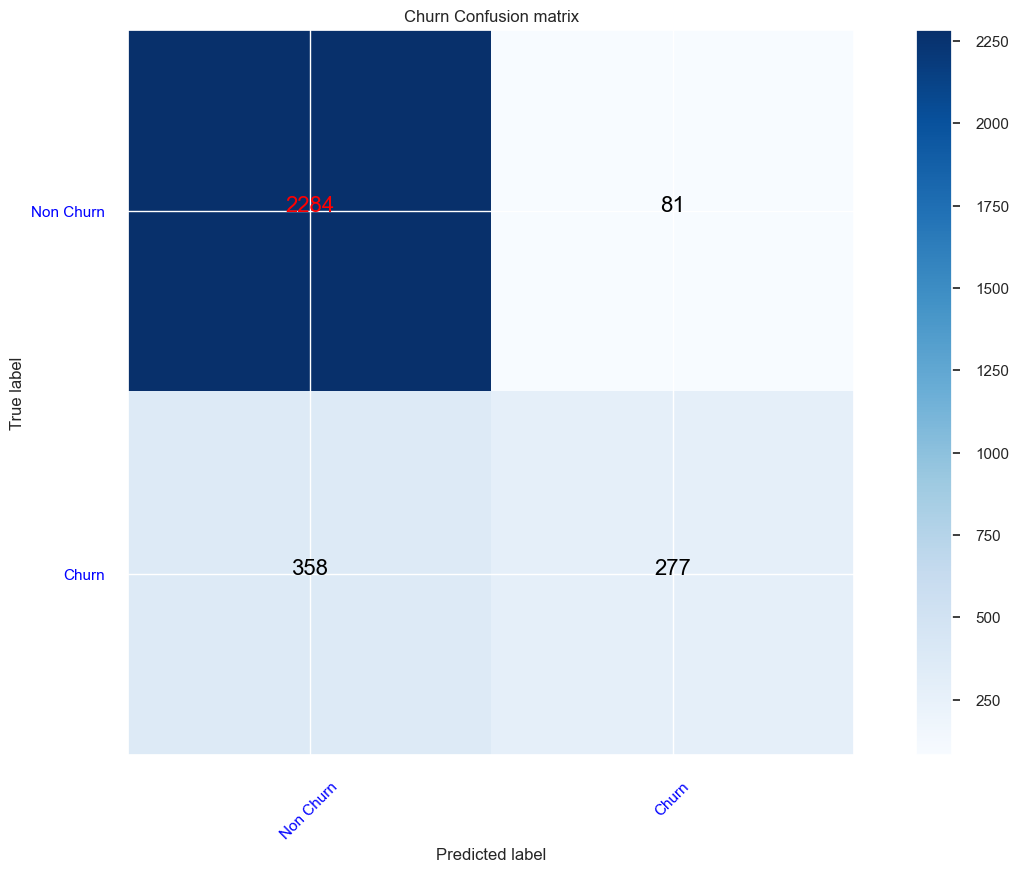

In [86]:
cfm = confusion_matrix(y_test, y_pred=y_pred)
plot_confusion_matrix(cfm, classes=['Non Churn','Churn'],
                      title='Churn Confusion matrix')


tn, fp, fn, tp = cfm.ravel()
print("True Negatives: ",tn)
print("False Positives: ",fp)
print("False Negatives: ",fn)
print("True Positives: ",tp)

[LightGBM] [Warning] Unknown parameter: silent


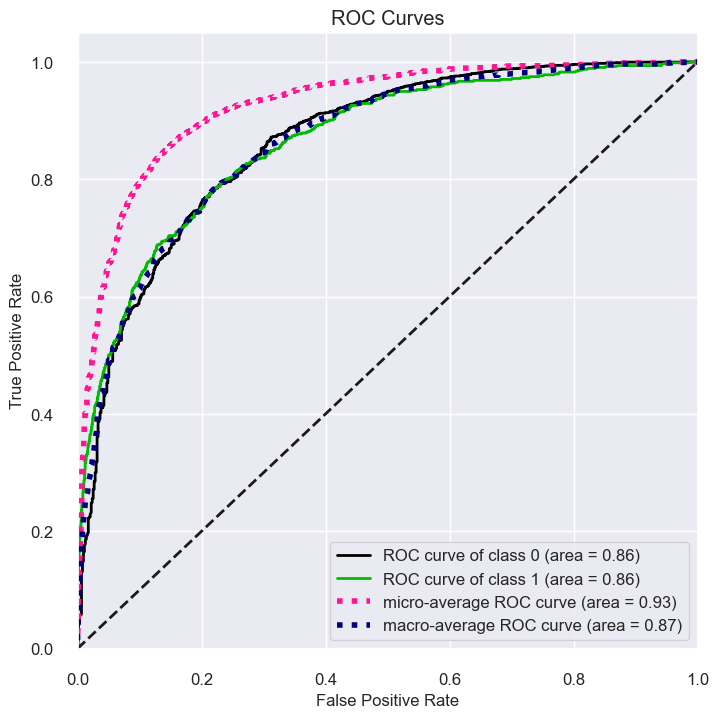

In [90]:
y_pred_proba = lgbm_model.predict_proba(X_test)
skplt.metrics.plot_roc_curve(y_test, y_pred_proba, figsize=(8,8))

plt.show()

In [91]:
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = model_prepare(df_model = data_encoded)

pipe = Pipeline([('xgboost', xgb_model)])

pipe.fit(X_train,y_train)
y_pred = pipe.predict(X_test)

print(classification_report(y_test,y_pred,digits=2))
print("Accuracy score of Tuned XGBoost Regression: ", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2365
           1       0.77      0.47      0.58       635

    accuracy                           0.86      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.85      0.86      0.84      3000

Accuracy score of Tuned XGBoost Regression:  0.8583333333333333


In [92]:
def prediction(model, df):
    data_feature = feature_engineering(df)
    data_encoded = data_encoding(data_feature)

    prediction = model.predict(data_encoded)

    df['ExitedPred'] = prediction.tolist()

    return prediction

In [93]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: C:\Users\shahr\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [96]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# OR use class_weight
xgb_model = XGBClassifier(
    scale_pos_weight=10,  # Adjust based on class ratio
    learning_rate=0.31,
    max_depth=5,
    n_estimators=50,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [97]:
y_pred_xg = xgb_model.predict(X_test)
print(classification_report(y_test,y_pred,digits=2))
print("Accuracy score of Tuned XGBoost Regression: ", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91      2365
           1       0.77      0.47      0.58       635

    accuracy                           0.86      3000
   macro avg       0.82      0.72      0.75      3000
weighted avg       0.85      0.86      0.84      3000

Accuracy score of Tuned XGBoost Regression:  0.8583333333333333


In [98]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

xgb_model = XGBClassifier(
    scale_pos_weight=5,
    learning_rate=0.31,
    max_depth=5,
    n_estimators=50,
    eval_metric="logloss"
)
xgb_model.fit(X_train_smote, y_train_smote)
y_pred = xgb_model.predict(X_test)
print(classification_report(y_test, y_pred, digits=2))

              precision    recall  f1-score   support

           0       0.93      0.75      0.83      2365
           1       0.45      0.78      0.57       635

    accuracy                           0.75      3000
   macro avg       0.69      0.76      0.70      3000
weighted avg       0.83      0.75      0.77      3000



In [99]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ===== HANDLE CLASS IMBALANCE =====
print(f"Original class distribution:\n{y_train.value_counts()}\n")

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"After SMOTE:\n{pd.Series(y_train_smote).value_counts()}\n")

# ===== TRAIN FINAL MODEL =====
final_model = XGBClassifier(
    scale_pos_weight=8,  # Penalize false negatives (missed churners)
    learning_rate=0.31,
    max_depth=5,
    n_estimators=50,
    eval_metric="logloss",
    random_state=42
)

final_model.fit(X_train_smote, y_train_smote)
y_pred = final_model.predict(X_test)
y_pred_proba = final_model.predict_proba(X_test)

# ===== EVALUATE =====
print("="*60)
print("FINAL MODEL PERFORMANCE")
print("="*60)
print(classification_report(y_test, y_pred, digits=2))
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_proba[:, 1]):.4f}")

# ===== CONFUSION MATRIX =====
cfm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(f"True Negatives:  {cfm[0,0]}")
print(f"False Positives: {cfm[0,1]}")
print(f"False Negatives: {cfm[1,0]} ← Missed churners (minimized)")
print(f"True Positives:  {cfm[1,1]} ← Caught churners (maximized)")

# Save model
import pickle
with open('api/models/final_churn_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print("\n✅ Model saved as 'final_churn_model.pkl'")

Original class distribution:
Exited
0    5596
1    1401
Name: count, dtype: int64

After SMOTE:
Exited
0    5596
1    5596
Name: count, dtype: int64

FINAL MODEL PERFORMANCE
              precision    recall  f1-score   support

           0       0.94      0.67      0.78      2365
           1       0.40      0.83      0.54       635

    accuracy                           0.70      3000
   macro avg       0.67      0.75      0.66      3000
weighted avg       0.82      0.70      0.73      3000


Accuracy: 0.7010
ROC-AUC: 0.8465

Confusion Matrix:
True Negatives:  1577
False Positives: 788
False Negatives: 109 ← Missed churners (minimized)
True Positives:  526 ← Caught churners (maximized)

✅ Model saved as 'final_churn_model.pkl'


In [100]:
import pandas as pd
import pickle

# Load model
with open('api/models/final_churn_model.pkl', 'rb') as f:
    model = pickle.load(f)

# Get predictions
churn_data = data_encoded.copy()
churn_data['Churn_Probability'] = model.predict_proba(
    churn_data.drop('Exited', axis=1)
)[:, 1]

# Create risk segments
def risk_segment(prob):
    if prob >= 0.70:
        return 'High Risk'
    elif prob >= 0.40:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn_data['Risk_Segment'] = churn_data['Churn_Probability'].apply(risk_segment)

# Merge with original data
final_export = data[[
    'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
    'EstimatedSalary', 'Geography', 'Gender', 'IsActiveMember',
    'HasCrCard', 'Exited'
]].copy()

final_export['Churn_Probability'] = churn_data['Churn_Probability']
final_export['Risk_Segment'] = churn_data['Risk_Segment']
final_export['CustomerID'] = range(1, len(data) + 1)

# Save
final_export.to_csv('churn_predictions_for_powerbi.csv', index=False)
print("✅ CSV ready for Power BI!")
print(f"Risk Distribution:\n{final_export['Risk_Segment'].value_counts()}")

✅ CSV ready for Power BI!
Risk Distribution:
Risk_Segment
High Risk      7139
Medium Risk    2364
Low Risk        494
Name: count, dtype: int64


In [101]:
# After your data is ready for training
print("="*70)
print("FEATURES USED IN MODEL")
print("="*70)
print(f"Shape: {X_train.shape}")
print(f"Number of Features: {X_train.shape[1]}")
print(f"\nFeature Names:")
for i, col in enumerate(X_train.columns, 1):
    print(f"{i:2d}. {col}")
print("="*70)

# Also save to file for API reference
feature_info = {
    'num_features': X_train.shape[1],
    'feature_names': X_train.columns.tolist(),
    'expected_shape': list(X_train.shape)
}

import json
with open('models/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

print("✅ Feature info saved to models/feature_info.json")

FEATURES USED IN MODEL
Shape: (6997, 24)
Number of Features: 24

Feature Names:


AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [102]:
# Look for where X was created/encoded
# Search for lines like: X = data_encoded or X = data.drop()

# Print BEFORE it becomes numpy array
print("="*70)
print("CHECKING DATA AT DIFFERENT STAGES")
print("="*70)

# 1. Original data
print(f"\nOriginal data shape: {data.shape}")
print(f"Original columns: {data.columns.tolist()}")

# 2. After encoding (if you have it)
# Look for this in your notebook:
# if 'data_encoded' exists:
if 'data_encoded' in dir():
    print(f"\nEncoded data shape: {data_encoded.shape}")
    print(f"Encoded columns: {data_encoded.columns.tolist()}")

# 3. After train/test split (BEFORE numpy conversion)
# Look for this:
# if 'X' exists and is DataFrame:
if isinstance(X, pd.DataFrame):  # X_train_smote might be array
    print(f"\nX shape: {X.shape}")
    print(f"X columns: {X.columns.tolist()}")

CHECKING DATA AT DIFFERENT STAGES

Original data shape: (10000, 14)
Original columns: ['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Encoded data shape: (9997, 25)
Encoded columns: ['RowNumber', 'CreditScore', 'Age', 'Balance', 'EstimatedSalary', 'Exited', 'balance_salary_rate', 'product_utilization_rate_by_year', 'product_utilization_rate_by_estimated_salary', 'tenure_rate_by_age', 'credit_score_rate_by_age', 'product_utilization_rate_by_salary', 'credit_score_rate_by_salary', 'mean_financials', 'credit_score_squared', 'age_tenure', 'countries_monthly_average_salaries', 'HasCrCard', 'IsActiveMember', 'NumOfProducts', 'Tenure', 'gender_category', 'country_category', 'credit_score_category', 'age_category']


NameError: name 'X' is not defined